# 05 — Student simulator

**Input:** `data/processed/features.parquet` (474,011 rows)
**Output:** fitted BKT parameters (`models/bkt_params.joblib`), two validation checks, and the simulated student used by the environment

### Why fit the simulator

The agent is trained and evaluated on simulated students. If I wrote the learning rules myself, the agent would just learn those rules back. Fitting BKT to real interactions means the learning dynamics come from data. The effects of the interventions are still assumptions, and they are kept together in `interventions.py` (notebook 06).

### BKT

BKT (Corbett & Anderson, 1995) is a two-state hidden Markov model with four parameters per skill:

| | |
|---|---|
| **L0** | probability the student knows the skill before practice |
| **T** | probability of learning it at a step |
| **G** | probability of a correct answer without knowing it (guess) |
| **S** | probability of a wrong answer despite knowing it (slip) |

$$P(\text{correct}) = L(1-S) + (1-L)G$$

After each answer the mastery estimate is updated with Bayes' rule, then learning is applied:

$$L' = \frac{L(1-S)}{L(1-S)+(1-L)G} \quad\text{(correct)}, \qquad L_{next} = L' + (1-L')T$$

Because a hint marks the item incorrect, `correct` here means "answered correctly without help".

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EATS = Path(r"C:\Users\vedac\Desktop\EATS")
sys.path.insert(0, str(EATS))
PROCESSED = EATS / "data" / "processed"
FIGURES = EATS / "results" / "figures"
MODELS = EATS / "models"
MODELS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})
BLUE, RED, GREY = "#4C72B0", "#C44E52", "#7F7F7F"
SEED = 42

df = pd.read_parquet(PROCESSED / "features.parquet")
SKILLS = list(pd.unique(df["skill"]))
SHORT = {
    "Addition and Subtraction Fractions": "Add/Sub Fractions",
    "Multiplication Fractions": "Mult Fractions",
    "Division Fractions": "Div Fractions",
    "Equation Solving Two or Fewer Steps": "Equations <=2",
    "Equation Solving More Than Two Steps": "Equations >2",
}
print(f"{len(df):,} rows | {df['user_id'].nunique():,} students | {len(SKILLS)} skills")

474,011 rows | 12,119 students | 5 skills


## 5.1 Fitting module

The cell below writes `eats/simulator/bkt.py`.

Without limits, the fit can return guess or slip above 0.5, which would mean a student who knows the skill is more likely to get it wrong (Baker, Corbett & Aleven, 2008). Guess and slip are capped at 0.30.

In [2]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/simulator/bkt.py
"""Bayesian Knowledge Tracing: fitting a student model to real interaction data."""

from __future__ import annotations

from dataclasses import asdict, dataclass

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Bounds. Guess and slip capped at 0.3 to prevent degenerate fits where knowing
# the skill makes a correct answer LESS likely (Baker, Corbett & Aleven, 2008).
BOUNDS = [(0.01, 0.99),   # L0
          (0.01, 0.99),   # T
          (0.01, 0.30),   # G
          (0.01, 0.30)]   # S

MAX_OPPORTUNITIES = 50
N_RESTARTS = 5


@dataclass
class BKTParams:
    skill: str
    L0: float
    T: float
    G: float
    S: float
    n_students: int
    n_interactions: int
    log_likelihood: float

    def p_correct(self, mastery):
        """Probability of an unaided correct answer at this mastery level."""
        return mastery * (1 - self.S) + (1 - mastery) * self.G

    def update(self, mastery, correct):
        """Bayesian posterior given the observation, then the learning transition."""
        if correct:
            num = mastery * (1 - self.S)
            den = num + (1 - mastery) * self.G
        else:
            num = mastery * self.S
            den = num + (1 - mastery) * (1 - self.G)
        posterior = num / den if den > 0 else mastery
        return posterior + (1 - posterior) * self.T

    def learning_curve(self, n=25):
        """Closed-form marginal learning curve, unconditioned on any student.

        Each opportunity gives an independent chance T of learning, so
        L_t = 1 - (1-L0)(1-T)^(t-1), and P(correct) follows from guess and slip.
        """
        t = np.arange(1, n + 1)
        mastery = 1 - (1 - self.L0) * (1 - self.T) ** (t - 1)
        return t, mastery * (1 - self.S) + (1 - mastery) * self.G

    def as_dict(self):
        return asdict(self)


def build_sequence_matrix(frame, max_len=MAX_OPPORTUNITIES):
    """Pad per-student practice sequences into an [n_students, max_len] matrix.

    The forward recursion is sequential in time but independent across students,
    so stepping through time once and updating every student with numpy is much
    faster than looping in Python. The optimiser calls this many times.
    """
    frame = frame.sort_values(["user_id", "opportunity"])
    seqs = [
        g["correct"].to_numpy(dtype=np.float64)[:max_len]
        for _, g in frame.groupby("user_id", sort=False)
    ]
    seqs = [s for s in seqs if len(s) > 0]
    width = max(len(s) for s in seqs)

    obs = np.zeros((len(seqs), width))
    mask = np.zeros((len(seqs), width), dtype=bool)
    for i, s in enumerate(seqs):
        obs[i, : len(s)] = s
        mask[i, : len(s)] = True
    return obs, mask


def negative_log_likelihood(params, obs, mask):
    """How badly these four parameters explain the observed answers."""
    L0, T, G, S = params
    eps = 1e-10
    mastery = np.full(obs.shape[0], L0)
    total = 0.0

    for t in range(obs.shape[1]):
        active = mask[:, t]
        if not active.any():
            break

        p = np.clip(mastery * (1 - S) + (1 - mastery) * G, eps, 1 - eps)
        c = obs[:, t]
        total += (c * np.log(p) + (1 - c) * np.log(1 - p))[active].sum()

        num_c, num_i = mastery * (1 - S), mastery * S
        den_c = num_c + (1 - mastery) * G
        den_i = num_i + (1 - mastery) * (1 - G)
        post = np.where(c > 0.5, num_c / np.maximum(den_c, eps),
                        num_i / np.maximum(den_i, eps))
        mastery = np.where(active, post + (1 - post) * T, mastery)

    return -total


def fit_skill(frame, skill, seed=42):
    """Fit one skill's four parameters by bounded maximum likelihood."""
    obs, mask = build_sequence_matrix(frame)
    rng = np.random.default_rng(seed)

    best = None
    for _ in range(N_RESTARTS):
        # Random restarts, because the likelihood has local optima and a single start
        # may not find the best fit.
        x0 = np.array([rng.uniform(lo, hi) for lo, hi in BOUNDS])
        res = minimize(negative_log_likelihood, x0, args=(obs, mask),
                       bounds=BOUNDS, method="L-BFGS-B")
        if best is None or res.fun < best.fun:
            best = res

    L0, T, G, S = best.x
    return BKTParams(str(skill), float(L0), float(T), float(G), float(S),
                     int(obs.shape[0]), int(mask.sum()), float(-best.fun))


def simulate_sequences(params, n_students, n_opportunities, seed=0):
    """Generate correct/incorrect sequences from known parameters.

    Used for parameter recovery: generate from known values, refit, and check
    the values come back.
    """
    rng = np.random.default_rng(seed)
    rows = []
    for student in range(n_students):
        knows = rng.random() < params.L0
        for opp in range(1, n_opportunities + 1):
            correct = (rng.random() > params.S) if knows else (rng.random() < params.G)
            rows.append({"user_id": student, "opportunity": opp, "correct": int(correct)})
            if not knows and rng.random() < params.T:
                knows = True
    return pd.DataFrame(rows)


Overwriting C:/Users/vedac/Desktop/EATS/eats/simulator/bkt.py


In [3]:
from eats.simulator import bkt as bkt_mod

importlib.reload(bkt_mod)
from eats.simulator.bkt import BKTParams, fit_skill, simulate_sequences

print("module loaded")

module loaded


## 5.2 Fit the five skills

Five random restarts per skill, because the likelihood has local optima.

In [4]:
fitted = []
for skill in SKILLS:
    sub = df[df["skill"] == skill]
    print(f"fitting {SHORT.get(skill, skill):<20} {len(sub):>7,} interactions ...", flush=True)
    fitted.append(fit_skill(sub, skill, seed=SEED))

params = pd.DataFrame([p.as_dict() for p in fitted])
params["skill_short"] = params["skill"].map(SHORT)
params.to_csv(PROCESSED / "bkt_params.csv", index=False)

params[["skill_short", "L0", "T", "G", "S", "n_students", "n_interactions"]].round(3)

fitting Add/Sub Fractions    138,201 interactions ...
fitting Equations >2          50,675 interactions ...
fitting Equations <=2        176,819 interactions ...
fitting Div Fractions         51,874 interactions ...
fitting Mult Fractions        56,442 interactions ...


,skill_short,L0,T,G,S,n_students,n_interactions
0,Add/Sub Fractions,0.700,0.060,0.300,0.222,7179,126935
1,Equations >2,0.445,0.081,0.207,0.300,2809,47862
2,Equations <=2,0.800,0.043,0.300,0.214,6207,140829
3,Div Fractions,0.624,0.105,0.269,0.234,3797,51066
4,Mult Fractions,0.594,0.112,0.300,0.233,3763,52907


### Checking the parameters

- G or S exactly at 0.30 means the cap is active.
- A very small T (below 0.01) would mean almost no learning from practice, which wouldn't match the rising curves in notebook 02.
- A high L0 (above 0.8) would mean most students already knew the skill.

In [5]:
flags = []
for p in fitted:
    if abs(p.G - 0.30) < 1e-3:
        flags.append(f"{SHORT.get(p.skill)}: G pinned at the 0.30 bound")
    if abs(p.S - 0.30) < 1e-3:
        flags.append(f"{SHORT.get(p.skill)}: S pinned at the 0.30 bound")
    if p.T < 0.01:
        flags.append(f"{SHORT.get(p.skill)}: T = {p.T:.4f}, near zero")
    if p.L0 > 0.8:
        flags.append(f"{SHORT.get(p.skill)}: L0 = {p.L0:.3f}, very high prior")

print("\n".join(f"  FLAG  {f}" for f in flags) if flags
      else "  no parameters at bounds; all within sensible ranges")

  FLAG  Add/Sub Fractions: G pinned at the 0.30 bound
  FLAG  Equations >2: S pinned at the 0.30 bound
  FLAG  Equations <=2: G pinned at the 0.30 bound
  FLAG  Mult Fractions: G pinned at the 0.30 bound


## 5.3 Check 1 — parameter recovery

Generate data from known parameters (400 synthetic learners, 30 opportunities each), fit the model, and compare. This checks the fitting code, not the dataset.

In [6]:
truth = BKTParams("synthetic", L0=0.20, T=0.15, G=0.20, S=0.10,
                  n_students=0, n_interactions=0, log_likelihood=0.0)

synth = simulate_sequences(truth, n_students=400, n_opportunities=30, seed=7)
recovered = fit_skill(synth, "synthetic", seed=SEED)

rec = pd.DataFrame({
    "parameter": ["L0", "T", "G", "S"],
    "true": [truth.L0, truth.T, truth.G, truth.S],
    "recovered": [recovered.L0, recovered.T, recovered.G, recovered.S],
})
rec["abs_error"] = (rec["true"] - rec["recovered"]).abs()
print(rec.round(4).to_string(index=False))
print(f"\nmax absolute error: {rec['abs_error'].max():.4f}")
print("n = 400 simulated learners x 30 opportunities")

parameter  true  recovered  abs_error
       L0  0.20     0.1632     0.0368
        T  0.15     0.1581     0.0081
        G  0.20     0.1871     0.0129
        S  0.10     0.0980     0.0020

max absolute error: 0.0368
n = 400 simulated learners x 30 opportunities


## 5.4 Check 2 — fitted curves against real data

Predicted accuracy at each opportunity:

$$L_t = 1-(1-L_0)(1-T)^{t-1}, \qquad P(\text{correct at }t) = L_t(1-S)+(1-L_t)G$$

plotted against observed accuracy.

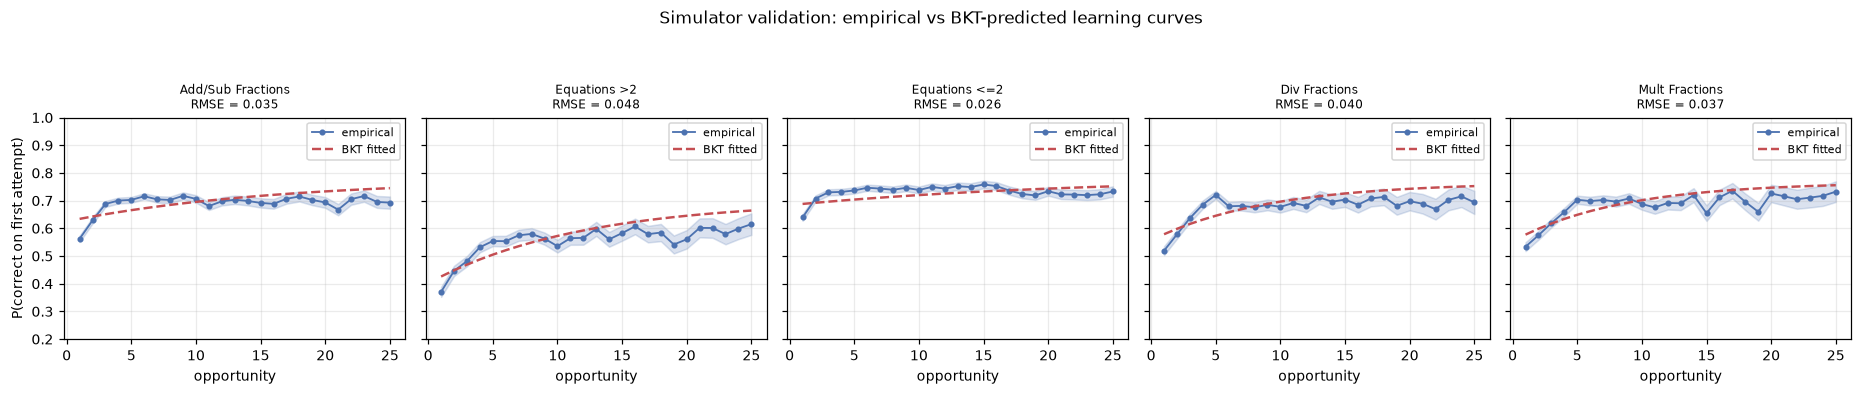

,skill,rmse,n_points
0,Add/Sub Fractions,0.0348,25
1,Equations >2,0.0478,25
2,Equations <=2,0.0261,25
3,Div Fractions,0.0405,25
4,Mult Fractions,0.0370,25


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.3), sharey=True)
MAX_OPP, MIN_N = 25, 50
rmse_rows = []

for ax, p in zip(axes, fitted):
    sub = df[df["skill"] == p.skill]
    emp = sub.groupby("opportunity")["correct"].agg(["mean", "size"])
    emp = emp[(emp.index <= MAX_OPP) & (emp["size"] >= MIN_N)]

    t, pred = p.learning_curve(MAX_OPP)
    pred_at = pd.Series(pred, index=t).reindex(emp.index)
    rmse = float(np.sqrt(((emp["mean"] - pred_at) ** 2).mean()))
    rmse_rows.append({"skill": SHORT.get(p.skill), "rmse": rmse,
                      "n_points": len(emp)})

    err = 1.96 * np.sqrt(emp["mean"] * (1 - emp["mean"]) / emp["size"])
    ax.plot(emp.index, emp["mean"], "o-", ms=3, lw=1.2, color=BLUE, label="empirical")
    ax.fill_between(emp.index, emp["mean"] - err, emp["mean"] + err, alpha=0.2, color=BLUE)
    ax.plot(t, pred, "--", lw=1.6, color=RED, label="BKT fitted")
    ax.set_ylim(0.2, 1.0)
    ax.set_xlabel("opportunity")
    ax.set_title(f"{SHORT.get(p.skill)}\nRMSE = {rmse:.3f}", fontsize=8)
    ax.legend(fontsize=7)

axes[0].set_ylabel("P(correct on first attempt)")
fig.suptitle("Simulator validation: empirical vs BKT-predicted learning curves", y=1.07)
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_11_bkt_validation.png", bbox_inches="tight")
plt.show()

pd.DataFrame(rmse_rows).round(4)

### Reading the plot

The predicted curve should follow the general shape of the observed one; exact agreement isn't expected. Per-skill RMSE is printed below.

Known BKT limitations that can explain differences:

- no forgetting (true mastery never goes down),
- all problems in a skill are treated as equally hard,
- all students share the same parameters.

## 5.5 Simulated student

BKT gives correctness only. Response time, hints and attempts are sampled from the real data, conditioned on skill and on whether the answer was correct. Simulated students therefore produce the same columns as real ones, and the same feature code works for both.

A correct answer always has zero hints, matching the data.

In [8]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/simulator/student.py
"""A simulated student: BKT dynamics plus empirically sampled observables."""

from __future__ import annotations

import numpy as np


class EmpiricalObservables:
    """Samples response time, hints and attempts from the real data.

    Conditioned on (skill, correct). Observed values are sampled directly, so no
    distribution shape has to be assumed.
    """

    def __init__(self, frame, skills):
        self.pools = {}
        for skill in skills:
            for correct in (0, 1):
                sub = frame[(frame["skill"] == skill) & (frame["correct"] == correct)]
                self.pools[(str(skill), correct)] = {
                    "ms": sub["ms_first_response"].to_numpy(dtype=np.float64),
                    "hints": sub["hint_count"].to_numpy(dtype=np.float64),
                    "attempts": sub["attempt_count"].to_numpy(dtype=np.float64),
                }

    def sample(self, skill, correct, rng):
        pool = self.pools[(str(skill), int(correct))]
        i = rng.integers(len(pool["ms"]))
        hints = 0.0 if correct else float(pool["hints"][i])
        return {
            "ms_first_response": float(pool["ms"][i]),
            "hint_count": hints,          # a hint forces incorrectness - never on a correct item
            "attempt_count": float(pool["attempts"][i]),
        }


class BKTStudent:
    """One simulated learner working through a single skill.

    `mastery` is the estimated probability that the student knows the skill.
    The agent never sees it; it only sees the observable features, as it would in
    a real system. The reward uses this value rather than observed accuracy.
    """

    def __init__(self, params, observables, rng=None):
        self.params = params
        self.observables = observables
        self.rng = rng or np.random.default_rng()
        self.reset()

    def reset(self):
        # Draw whether this student already knows the skill, then track belief.
        self.knows = self.rng.random() < self.params.L0
        self.mastery = self.params.L0
        self.opportunity = 0
        return self.mastery

    def answer(self):
        """Attempt one problem. Returns the observable record."""
        p = self.params
        if self.knows:
            correct = self.rng.random() > p.S
        else:
            correct = self.rng.random() < p.G

        obs = self.observables.sample(p.skill, int(correct), self.rng)
        self.opportunity += 1

        # True latent transition: an unknown skill may become known.
        if not self.knows and self.rng.random() < p.T:
            self.knows = True

        # Observer's belief, updated the same way a tutoring system would.
        self.mastery = p.update(self.mastery, correct)

        obs.update({"correct": float(correct), "opportunity": self.opportunity,
                    "mastery": self.mastery, "knows": bool(self.knows)})
        return obs


Writing C:/Users/vedac/Desktop/EATS/eats/simulator/student.py


In [9]:
from eats.simulator import student as student_mod

importlib.reload(student_mod)
from eats.simulator.student import BKTStudent, EmpiricalObservables

raw = pd.read_parquet(PROCESSED / "interactions_clean.parquet")
obs_sampler = EmpiricalObservables(raw, SKILLS)
print("observable pools built for", len(obs_sampler.pools), "(skill, correct) combinations")

observable pools built for 10 (skill, correct) combinations


## 5.6 Simulated vs real cohort

Generate a cohort from the fitted parameters and compare it with the real data.

In [10]:
rng = np.random.default_rng(SEED)
N_SIM, N_OPP = 500, 25
sim_rows = []

for p in fitted:
    for i in range(N_SIM):
        s = BKTStudent(p, obs_sampler, rng)
        for _ in range(N_OPP):
            r = s.answer()
            r["skill"] = p.skill
            r["user_id"] = f"sim_{p.skill[:6]}_{i}"
            sim_rows.append(r)

sim = pd.DataFrame(sim_rows)
print(f"simulated {len(sim):,} interactions from {N_SIM} students x {len(fitted)} skills")

comparison = pd.DataFrame({
    "real": [
        raw["correct"].mean(),
        (raw["hint_count"] > 0).mean(),
        raw["attempt_count"].mean(),
        raw["ms_first_response"].median() / 1000,
    ],
    "simulated": [
        sim["correct"].mean(),
        (sim["hint_count"] > 0).mean(),
        sim["attempt_count"].mean(),
        sim["ms_first_response"].median() / 1000,
    ],
}, index=["accuracy", "hint rate", "mean attempts", "median response time (s)"])
comparison["difference"] = comparison["simulated"] - comparison["real"]
comparison.round(3)

simulated 62,500 interactions from 500 students x 5 skills


,real,simulated,difference
accuracy,0.681,0.679,-0.002
hint rate,0.171,0.183,0.012
mean attempts,1.366,1.362,-0.003
median response time (s),37.790,42.254,4.465


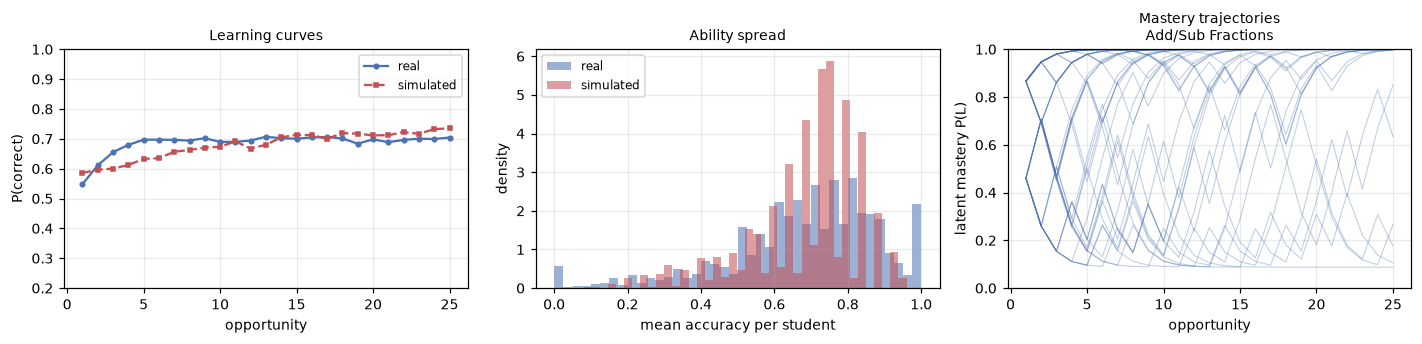

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

# Learning curves, real vs simulated, pooled across skills
real_curve = raw.groupby("opportunity")["correct"].mean().head(N_OPP)
sim_curve = sim.groupby("opportunity")["correct"].mean().head(N_OPP)
axes[0].plot(real_curve.index, real_curve.values, "o-", ms=3, color=BLUE, label="real")
axes[0].plot(sim_curve.index, sim_curve.values, "s--", ms=3, color=RED, label="simulated")
axes[0].set_xlabel("opportunity"); axes[0].set_ylabel("P(correct)")
axes[0].set_title("Learning curves", fontsize=9); axes[0].legend(fontsize=8)
axes[0].set_ylim(0.2, 1.0)

# Per-student accuracy distributions
real_acc = raw.groupby("user_id")["correct"].mean()
sim_acc = sim.groupby("user_id")["correct"].mean()
axes[1].hist(real_acc, bins=40, density=True, alpha=0.55, color=BLUE, label="real")
axes[1].hist(sim_acc, bins=40, density=True, alpha=0.55, color=RED, label="simulated")
axes[1].set_xlabel("mean accuracy per student"); axes[1].set_ylabel("density")
axes[1].set_title("Ability spread", fontsize=9); axes[1].legend(fontsize=8)

# Latent mastery trajectories - what the agent will be rewarded on
for i in range(40):
    s = BKTStudent(fitted[0], obs_sampler, rng)
    traj = [s.answer()["mastery"] for _ in range(N_OPP)]
    axes[2].plot(range(1, N_OPP + 1), traj, lw=0.7, alpha=0.35, color=BLUE)
axes[2].set_xlabel("opportunity"); axes[2].set_ylabel("latent mastery P(L)")
axes[2].set_title(f"Mastery trajectories\n{SHORT.get(fitted[0].skill)}", fontsize=9)
axes[2].set_ylim(0, 1)

fig.tight_layout()
fig.savefig(FIGURES / "fig_4_12_simulator_validation.png", bbox_inches="tight")
plt.show()

The third plot shows mastery, which the reward is based on. The agent doesn't see it; it only sees the observable features. Observed accuracy can be pushed up by giving easier questions, which is why the reward doesn't use it.

In [12]:
import joblib

joblib.dump({"params": [p.as_dict() for p in fitted], "skills": SKILLS,
             "seed": SEED, "n_restarts": bkt_mod.N_RESTARTS,
             "bounds": bkt_mod.BOUNDS},
            MODELS / "bkt_params.joblib")
print(f"saved {MODELS / 'bkt_params.joblib'}")
print(f"saved {PROCESSED / 'bkt_params.csv'}")

saved C:\Users\vedac\Desktop\EATS\models\bkt_params.joblib
saved C:\Users\vedac\Desktop\EATS\data\processed\bkt_params.csv
